In [42]:
import datetime
import mlflow
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from optuna.samplers import TPESampler
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    roc_curve,
    accuracy_score,
    f1_score,
    auc,
    classification_report,
)

from sklearn.preprocessing import (
    label_binarize,
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    LabelEncoder,
)

import sys

sys.path.append("../src")

from experiment_tracking import (
    champion_callback,
    get_or_create_experiment,
    plot_feature_importance,
)
from feature_engineering import create_all_features
from preprocessing import combine_train_and_original_dfs, preprocess_df

warnings.filterwarnings("ignore")
# override Optuna's default logging to ERROR only
optuna.logging.set_verbosity(optuna.logging.ERROR)

In [7]:
target = "NObeyesdad"
random_state = 0
current_datetime = datetime.datetime.now().strftime("%Y-%m-%d_%H%M")
run_name = f"{current_datetime}_single_add_feats"

In [43]:
n_trials = 5

## Initializing the MLflow Client

In [8]:
mlflow.set_tracking_uri("http://127.0.0.1:5000/")

## Create experiment

In [10]:
experiment_id = get_or_create_experiment("Obesity Prediction")
print(experiment_id)

994266685072118732


## Set up MLflow - Initialisation

In [11]:
# Set the current active MLflow experiment
mlflow.set_experiment(experiment_id=experiment_id)

<Experiment: artifact_location='mlflow-artifacts:/994266685072118732', creation_time=1708938814113, experiment_id='994266685072118732', last_update_time=1708938814113, lifecycle_stage='active', name='Obesity Prediction', tags={}>

## Data preprocessing

In [16]:
# Load data
df_train = pd.read_csv("../data/raw/train.csv")
df_test = pd.read_csv("../data/raw/test.csv")
df_original = pd.read_csv("../data/raw/ObesityDataSet.csv")
submission = pd.read_csv("../data/raw/sample_submission.csv")


train = combine_train_and_original_dfs(df_train, df_original)
X_test = df_test.drop(["id"], axis=1)

## Feature Engineering

In [20]:
cat_cols = X_test.select_dtypes(include=[object]).columns.tolist()
print(cat_cols)

['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']


In [27]:
train_ohe = pd.get_dummies(train, columns=cat_cols, drop_first=True)
X_test_ohe = pd.get_dummies(df_test, columns=cat_cols, drop_first=True)

In [28]:
train_ohe.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,24.443011,1.699998,81.669950,2.000000,2.983297,2.763573,0.000000,0.976473,Overweight_Level_II,True,...,False,False,False,False,True,False,False,False,True,False
1,18.000000,1.560000,57.000000,2.000000,3.000000,2.000000,1.000000,1.000000,Normal_Weight,False,...,False,False,False,False,False,True,False,False,False,False
2,18.000000,1.711460,50.165754,1.880534,1.411685,1.910378,0.866045,1.673584,Insufficient_Weight,False,...,False,False,False,False,False,True,False,False,True,False
3,20.952737,1.710730,131.274851,3.000000,3.000000,1.674061,1.467863,0.780199,Obesity_Type_III,False,...,False,False,False,False,True,False,False,False,True,False
4,31.641081,1.914186,93.798055,2.679664,1.971472,1.979848,1.967973,0.931721,Overweight_Level_II,True,...,False,False,False,False,True,False,False,False,True,False


## Label Encoding

In [29]:
le = LabelEncoder()
train_ohe["NObeyesdad"] = le.fit_transform(train_ohe["NObeyesdad"])

In [30]:
train_ohe.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,NObeyesdad,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,24.443011,1.699998,81.669950,2.000000,2.983297,2.763573,0.000000,0.976473,6,True,...,False,False,False,False,True,False,False,False,True,False
1,18.000000,1.560000,57.000000,2.000000,3.000000,2.000000,1.000000,1.000000,1,False,...,False,False,False,False,False,True,False,False,False,False
2,18.000000,1.711460,50.165754,1.880534,1.411685,1.910378,0.866045,1.673584,0,False,...,False,False,False,False,False,True,False,False,True,False
3,20.952737,1.710730,131.274851,3.000000,3.000000,1.674061,1.467863,0.780199,4,False,...,False,False,False,False,True,False,False,False,True,False
4,31.641081,1.914186,93.798055,2.679664,1.971472,1.979848,1.967973,0.931721,6,True,...,False,False,False,False,True,False,False,False,True,False


## Train test split

In [33]:
X = train_ohe.drop([target], axis=1)
y = train_ohe[target]

# Train-test split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

In [34]:
X_train.shape, y_train.shape, X_valid.shape, y_valid.shape

((18276, 23), (18276,), (4569, 23), (4569,))

## Hyperparameter Tuning and Model Training using Optuna and MLflow

In [44]:
def optimization_function(trial):

    lgbParams = {
        "num_class": 7,
        "random_state": random_state,
        "metric": "multi_logloss",
        "boosting_type": "gbdt",
        "objective": "multiclass",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "n_estimators": trial.suggest_int("n_estimators", 400, 600),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-3, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-1, 10.0),
        "max_depth": trial.suggest_int("max_depth", 6, 20),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 0.9),
        "subsample": trial.suggest_float("subsample", 0.8, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 50),
    }

    lgb_model = LGBMClassifier(**lgbParams)

    lgb_model.fit(X_train, y_train)

    acc = accuracy_score(y_valid, lgb_model.predict(X_valid))

    return acc

[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Warning] Accuracy may be bad since you didn't explicitly set num_leaves OR 2^max_depth > num_leaves. (num_leaves=31).
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2058
[LightGBM] [Info] Number of data points in the train set: 18276, number of used features: 21
[LightGBM] [Info] Start training from score -2.096438
[LightGBM] [Info] Start training from score -1.918281
[LightGBM] [Info] Start training from score -1.940508
[LightGBM] [Info] Start training from score -1.869561
[LightGBM] [Info] Start training from score -1.661722
[LightGBM] [Info] Start training from score -2.112596
[LightGBM] [Info] Start training from score -2.106281
[LightGBM

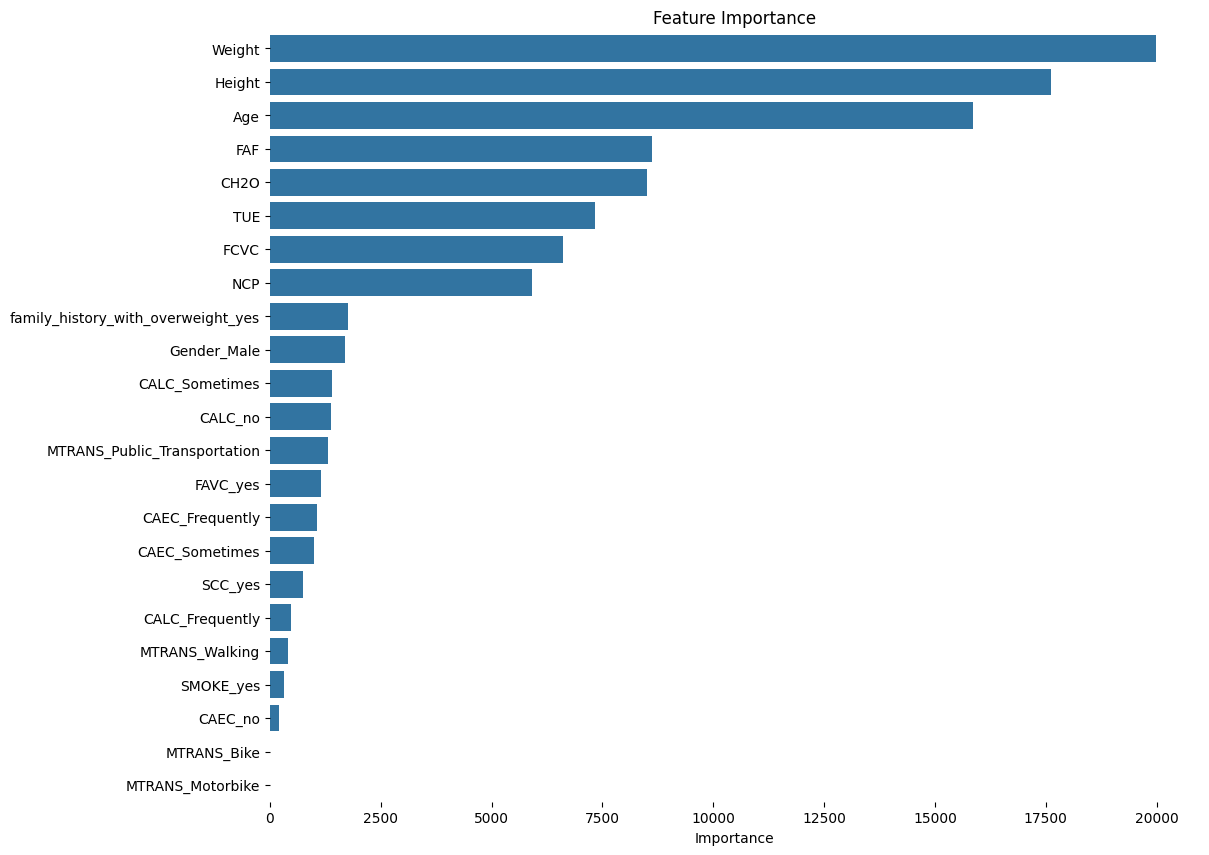

In [45]:
# Initiate the parent run and call the hyperparameter tuning child run logic
with mlflow.start_run(experiment_id=experiment_id, run_name=run_name, nested=True):

    # Set up the sampler for Optuna optimization
    sampler = optuna.samplers.TPESampler(seed=random_state)  # Using Tree-structured Parzen Estimator sampler for optimization

    # Initialize the Optuna study
    study = optuna.create_study(direction="maximize", sampler=sampler)

    # Execute the hyperparameter optimization trials.
    # Note the addition of the `champion_callback` inclusion to control our logging
    study.optimize(
        optimization_function,
        n_trials=n_trials,
        callbacks=[champion_callback],
    )

    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_accuracy", study.best_value)

    # Log tags
    mlflow.set_tags(
        tags={
            "project": "Obesity Prediction Project",
            "optimizer_engine": "optuna",
            "model_family": "lightGBM",
            "feature_set_version": 1,
        }
    )

    # Log a fit model instance
    model = LGBMClassifier(**study.best_params)
    print(study.best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    # Log the feature importances plot
    importances = plot_feature_importance(model, X=X)
    mlflow.log_figure(figure=importances, artifact_file="feature_importances.png")

    artifact_path = "model"

    model_info = mlflow.lightgbm.log_model(
        lgb_model=model,
        name=artifact_path,
        input_example=X_train.iloc[[0]],
        metadata={"model_data_version": 1},
    )

    # Get the logged model uri so that we can load it from the artifact store
    model_uri = model_info.model_uri

    ran_optuna = True

In [53]:
model_uri

'mlflow-artifacts:/994266685072118732/4fae1b1f01f94efe80aeae73423cbf4b/artifacts/model'

In [46]:
if ran_optuna:

    print("Number of finished trials:", len(study.trials))
    print("Best trial:", study.best_trial.params)

    optuna.visualization.plot_param_importances(study)
    study.trials_dataframe().sort_values("value", ascending=False)
    optuna.visualization.plot_slice(study)

Number of finished trials: 5
Best trial: {'learning_rate': 0.028246013288661942, 'n_estimators': 514, 'reg_alpha': 0.001188937983177301, 'reg_lambda': 1.7189806743319385, 'max_depth': 15, 'colsample_bytree': 0.6701603981248542, 'subsample': 0.9887496157029249, 'min_child_samples': 37}


## Tuning and Re-training

In [47]:
if ran_optuna:
    lgbParams = study.best_trial.params

In [48]:
fixed_params = {
    "boosting_type": "gbdt",
    "num_class": 7,
    "random_state": random_state,
    "metric": "multi_logloss",
}

In [49]:
for i in fixed_params.keys():
    lgbParams[i] = fixed_params[i]

In [50]:
lgbParams

{'learning_rate': 0.028246013288661942,
 'n_estimators': 514,
 'reg_alpha': 0.001188937983177301,
 'reg_lambda': 1.7189806743319385,
 'max_depth': 15,
 'colsample_bytree': 0.6701603981248542,
 'subsample': 0.9887496157029249,
 'min_child_samples': 37,
 'boosting_type': 'gbdt',
 'num_class': 7,
 'random_state': 0,
 'metric': 'multi_logloss'}

In [59]:
lgb_final = LGBMClassifier(**lgbParams, verbosity=-1)

In [60]:
lgb_final = lgb_final.fit(X_train, y_train)

In [61]:
y_pred = lgb_final.predict(X_valid)

In [62]:
accuracy_score(y_valid, y_pred)

0.9194572116436857

In [64]:
y_pred_proba = lgb_final.predict_proba(X_valid)

In [65]:
X_valid = pd.concat(
    [
        X_valid.reset_index(),
        pd.DataFrame(
            {
                "actual": le.inverse_transform(y_valid),
                "guess": le.inverse_transform(y_pred),
            }
        ),
    ],
    axis=1,
)
X_valid["dummy"] = 1
X_valid.pivot_table(index="actual", columns="guess", values="dummy", aggfunc="sum")

guess,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
actual,,,,,,,
Insufficient_Weight,516.0,25.0,NaN,NaN,NaN,3.0,NaN
Normal_Weight,25.0,612.0,1.0,NaN,NaN,36.0,6.0
Obesity_Type_I,1.0,NaN,588.0,16.0,3.0,5.0,23.0
Obesity_Type_II,NaN,NaN,8.0,715.0,1.0,NaN,3.0
Obesity_Type_III,NaN,1.0,2.0,NaN,898.0,NaN,NaN
Overweight_Level_I,4.0,49.0,11.0,NaN,NaN,384.0,45.0
Overweight_Level_II,NaN,10.0,39.0,2.0,NaN,49.0,488.0


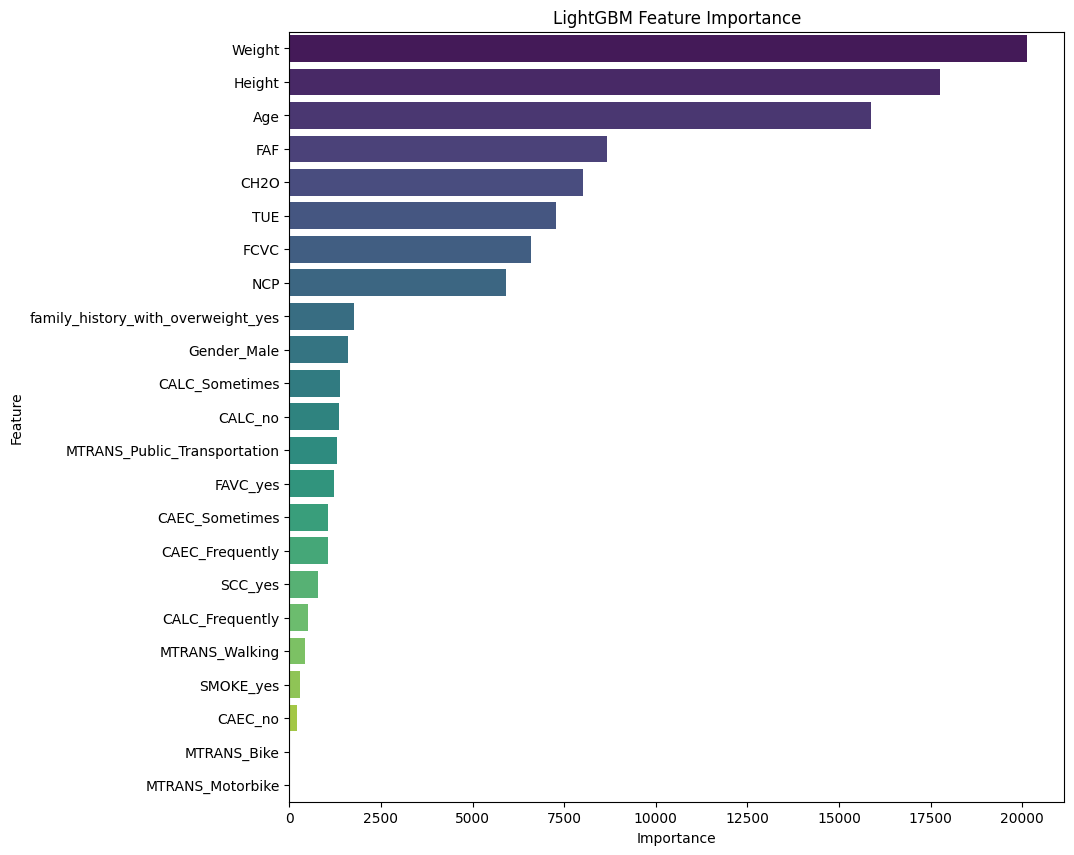

In [67]:
def plot_lgbm_feature_importance(model, feature_names=None, top_n=10, plot=True):

    # Get feature importance
    feature_importance = model.feature_importances_

    # Get feature names
    if feature_names is None:
        feature_names = model.feature_name()

    # Create DataFrame with feature names and importance scores
    feature_importance_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": feature_importance}
    )

    # Sort by importance and select top features
    feature_importance_df = feature_importance_df.sort_values(
        by="Importance", ascending=False
    )  # .head(top_n)

    # Plot the feature importance
    if plot:
        plt.figure(figsize=(10, 10))
        sns.barplot(
            x="Importance", y="Feature", data=feature_importance_df, palette="viridis"
        )
        plt.title("LightGBM Feature Importance")
        plt.show()

    return feature_importance_df


feature_importance_df = plot_lgbm_feature_importance(
    lgb_final, feature_names=X_train.columns
)

## Plot SHAP

In [68]:
import shap


def plot_shap_summary(model, X, plot_type="bar", plot=True):

    # Create a SHAP explainer object
    explainer = shap.TreeExplainer(model)

    # Calculate SHAP values
    shap_values = explainer.shap_values(X)

    return shap_values

In [69]:
shap_values = plot_shap_summary(
    lgb_final, pd.DataFrame(data=X_train, columns=X_train.columns)
)

['Insufficient_Weight']


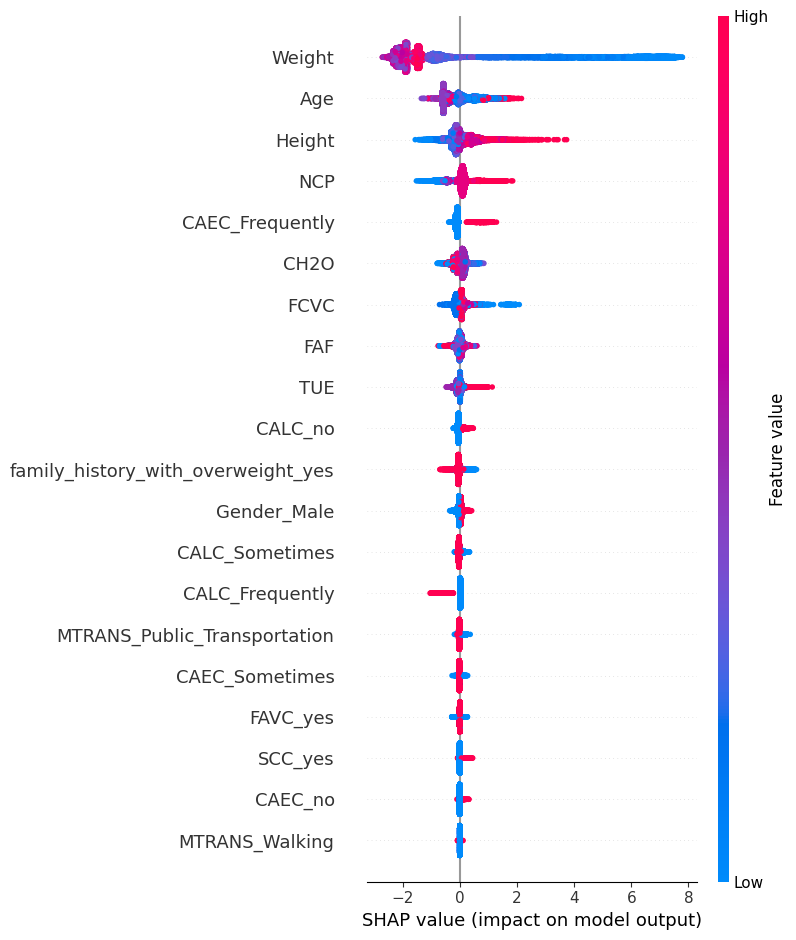

['Normal_Weight']


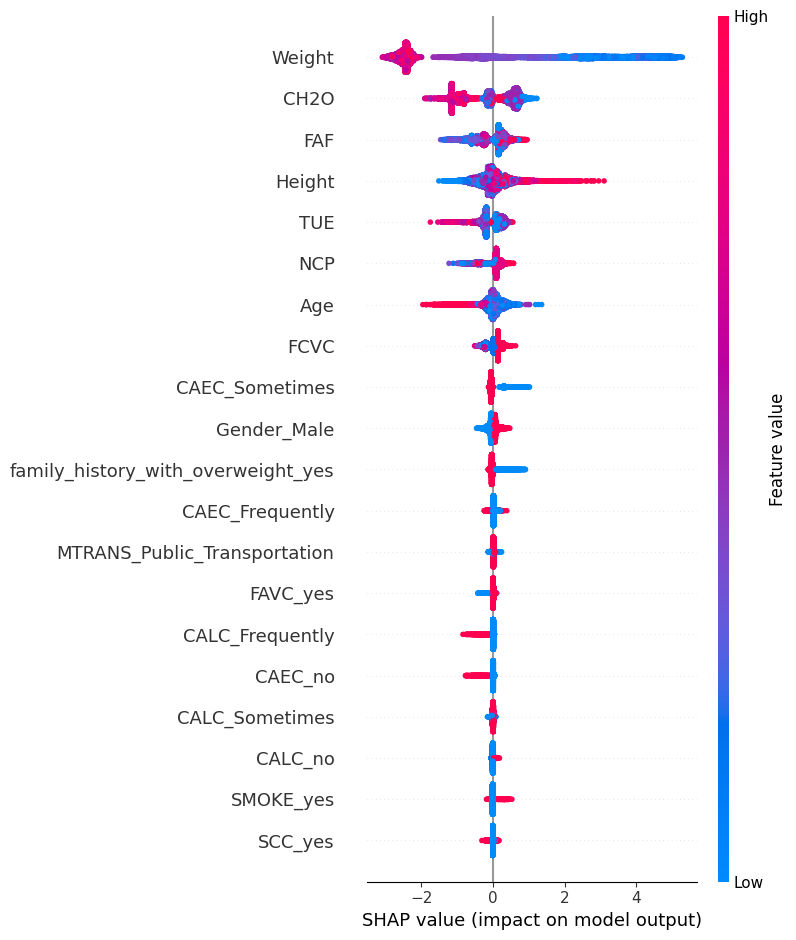

['Obesity_Type_I']


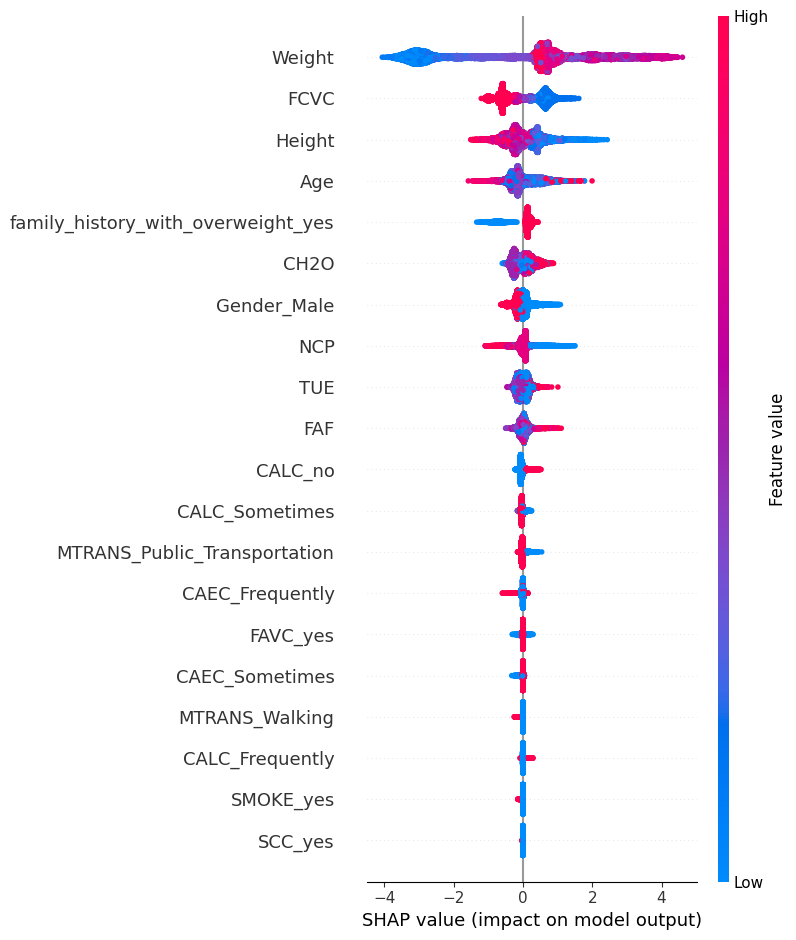

['Obesity_Type_II']


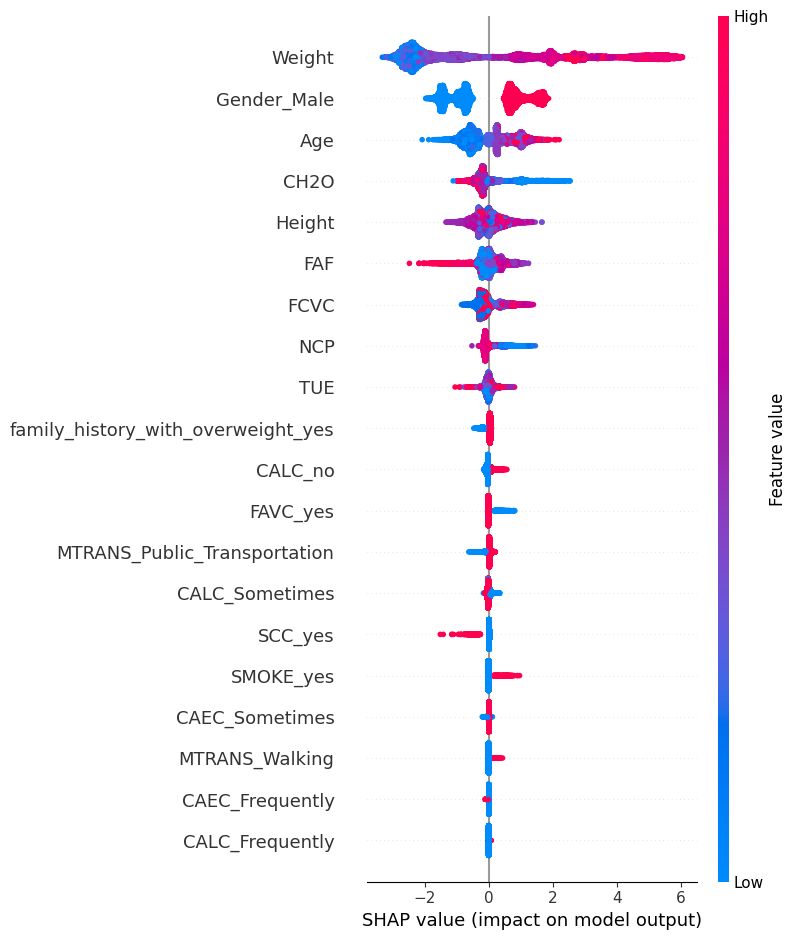

['Obesity_Type_III']


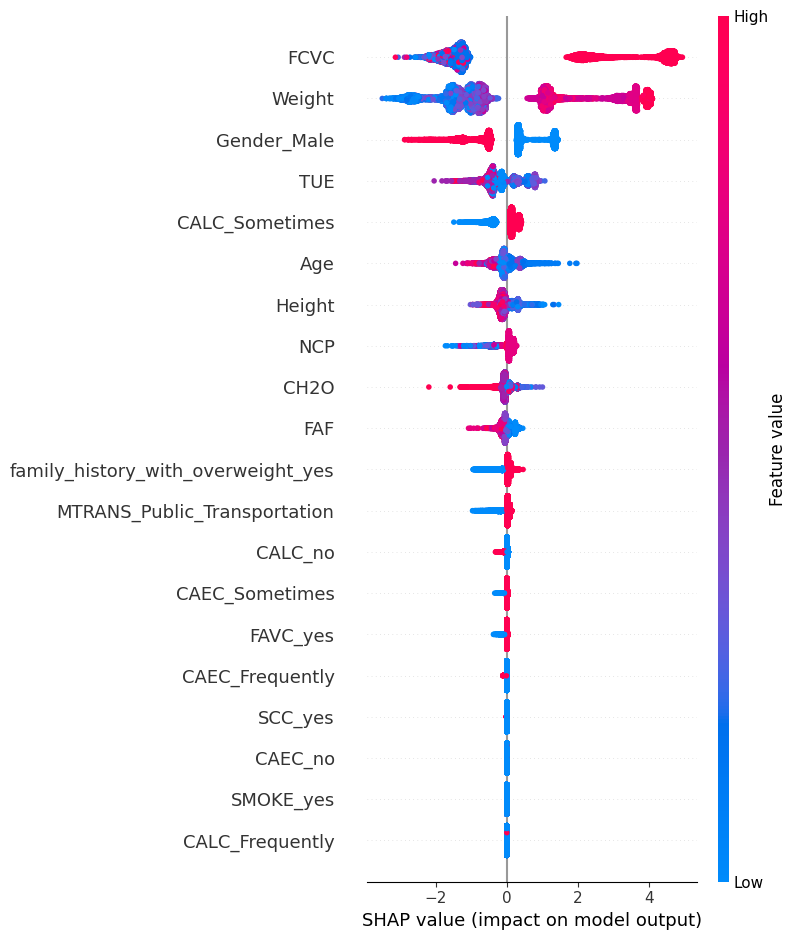

['Overweight_Level_I']


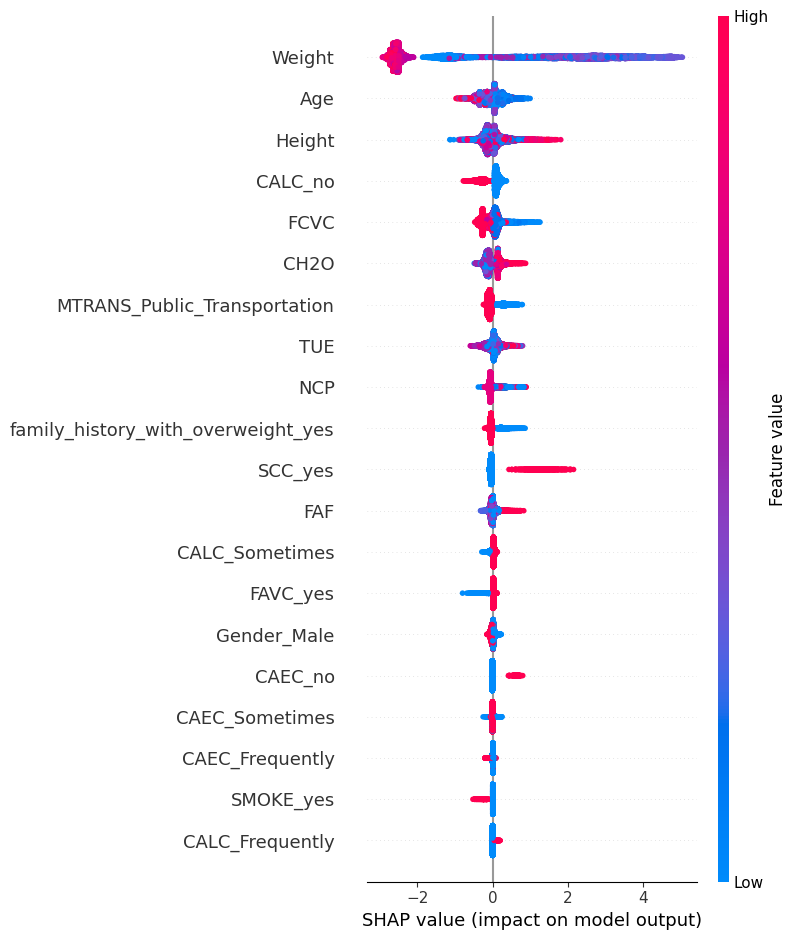

['Overweight_Level_II']


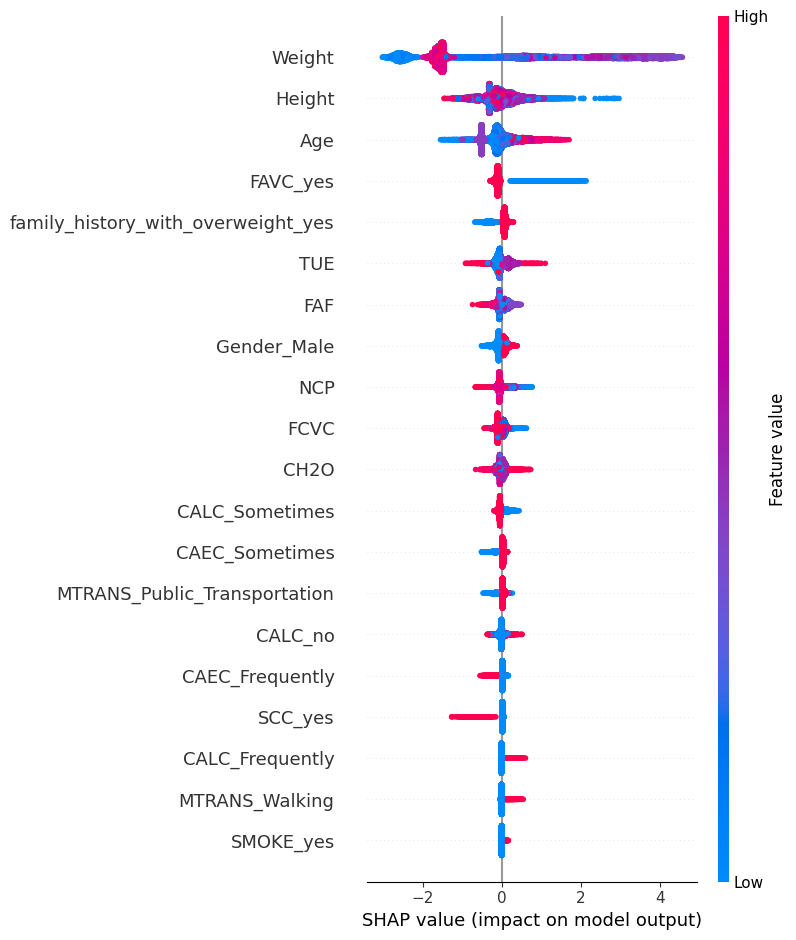

In [70]:
for x in range(len(shap_values)):
    print("=" * 50)
    print(le.inverse_transform([x]))
    shap.summary_plot(
        shap_values[x], pd.DataFrame(data=X_train, columns=X_train.columns))

## Threshold Optimisation

In [71]:
threshold_optimization = True
run_optuna_threshold = True

In [72]:
def threshold_objective(trial):

    # Define the thresholds for each class
    thresholds = {}
    for i in range(num_classes):
        thresholds[f"threshold_{i}"] = trial.suggest_uniform(f"threshold_{i}", 0.0, 1.0)

    # Apply the thresholds to convert probabilities to predictions
    y_pred = apply_thresholds(y_pred_proba, thresholds)

    # Calculate accuracy
    accuracy = accuracy_score(y_valid, y_pred)

    return accuracy


def apply_thresholds(y_proba, thresholds):
    # Apply the specified thresholds to convert probabilities to predicted labels
    y_pred_labels = np.argmax(y_proba, axis=1)
    for i in range(y_proba.shape[1]):
        y_pred_labels[y_proba[:, i] > thresholds[f"threshold_{i}"]] = i

    return y_pred_labels

In [75]:
if run_optuna_threshold:
    with mlflow.start_run(experiment_id=experiment_id, run_name=run_name, nested=True):

        num_classes = 7
        y_pred_proba = y_pred_proba
        y_val = y_valid

        study = optuna.create_study(direction="maximize")
        study.optimize(threshold_objective, n_trials=n_trials)

        # Get the best thresholds
        best_thresholds = study.best_params
        print("Best Thresholds:", best_thresholds)
        print("Best Value:", study.best_value)
        threshold_optimization = True

        mlflow.log_params(study.best_params)
        #mlflow.log_metric("best_threshold", best_thresholds)
        mlflow.log_metric("best_value", study.best_value)

Best Thresholds: {'threshold_0': 0.7686681771953292, 'threshold_1': 0.5290391005611876, 'threshold_2': 0.6703480479258972, 'threshold_3': 0.6410829279052346, 'threshold_4': 0.2546746667887708, 'threshold_5': 0.8263835147880488, 'threshold_6': 0.40477373521242865}
Best Value: 0.919676077916393
